In [1]:
from pylab import *

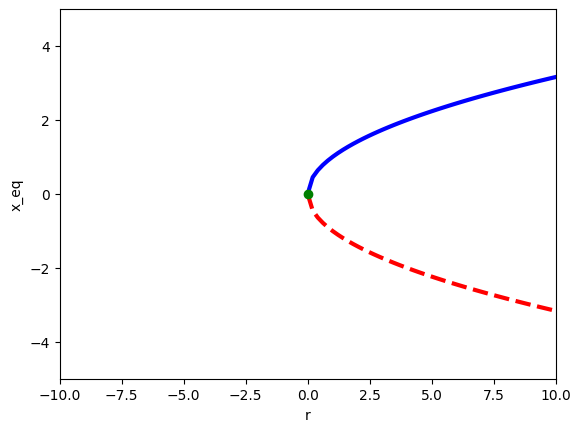

In [ ]:
def xeq1(r):
    return sqrt(r)
def xeq2(r):
    return -sqrt(r)
domain = linspace(0, 10)
plot(domain, xeq1(domain), 'b-', linewidth = 3)
plot(domain, xeq2(domain), 'r--', linewidth = 3)
plot([0], [0], 'go')
axis([-10, 10, -5, 5])
xlabel('r')
ylabel('x_eq')
show()

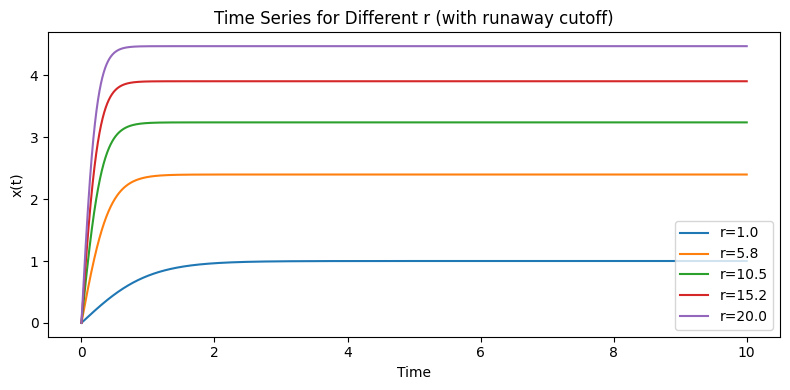

In [14]:
import matplotlib.pyplot as plt

# time‐step
Dt = 0.0001

# make this a list so the order is preserved
r_list = np.linspace(1, 20, 5)
x_cutoff = 100.0   # stop if |x| grows beyond this

def initialize():
    global x, xresult, t, timestamp
    x = 0.0
    xresult = [x]
    t = 0.0
    timestamp = [t]

def observe():
    global x, xresult, t, timestamp
    xresult.append(x)
    timestamp.append(t)

def update(r):
    global x, t
    x = x + (r - x**2) * Dt
    t = t + Dt

# run and plot
plt.figure(figsize=(8,4))
for r in r_list:
    initialize()
    # keep going until t=10 or |x| runs away
    while t < 10 and abs(x) < x_cutoff:
        update(r)
        observe()
    plt.plot(timestamp, xresult, label=f'r={r:.1f}')

plt.xlabel('Time')
plt.ylabel('x(t)')
plt.legend()
plt.title('Time Series for Different r (with runaway cutoff)')
plt.tight_layout()
plt.show()


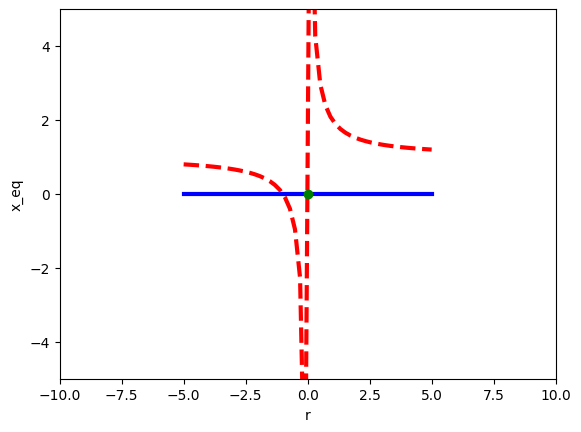

In [10]:
def xeq3(r):
    return r*0
def xeq4(r):
    return (r+1)/r

domain = linspace(-5, 5)
plot(domain, xeq3(domain), 'b-', linewidth = 3)
plot(domain, xeq4(domain), 'r--', linewidth = 3)
plot([0], [0], 'go')
axis([-10, 10, -5, 5])
xlabel('r')
ylabel('x_eq')
show()

In [5]:
import numpy as np

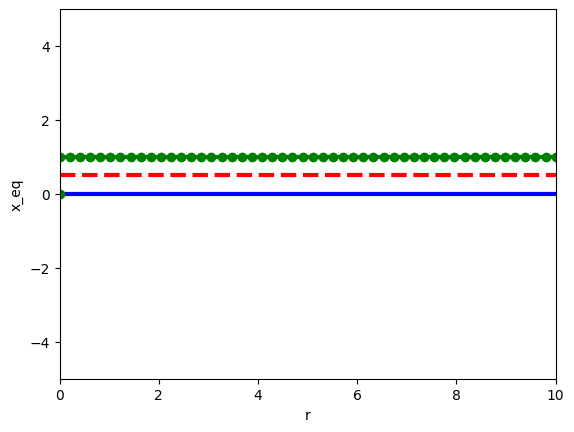

In [7]:
def xeq1(r):
    return 0*np.ones_like(r)
def xeq2(r):
    return 0.5*np.ones_like(r)
def xeq3(r):
    return 1*np.ones_like(r)

domain = linspace(0, 10)
plot(domain, xeq1(domain), 'b-', linewidth = 3)
plot(domain, xeq2(domain), 'r--', linewidth = 3)
plot(domain, xeq3(domain), 'g-o', linewidth = 3)
plot([0], [0], 'go')
axis([0, 10, -5, 5])
xlabel('r')
ylabel('x_eq')
show()

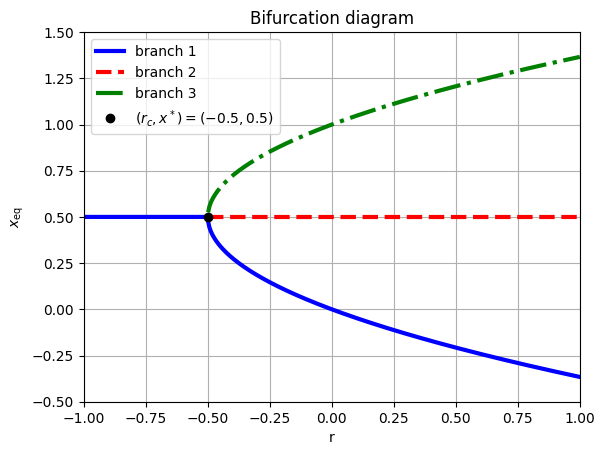

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def xeq_branches(r):
    """
    Returns the real equilibria x* solving
        x(1−x)(2x−1) + r(0.5−x) = 0
    as a sorted list.
    """
    # coefficients of 2x^3 − 3x^2 + (1−r)x + 0.5·r = 0
    coeffs = [2.0, -3.0, 1.0 - r, 0.5 * r]
    roots = np.roots(coeffs)
    real_roots = sorted([rt.real for rt in roots if abs(rt.imag) < 1e-6])
    return real_roots

# 1) Create a domain of r-values
domain = np.linspace(-1, 1, 400)

# 2) For each branch, build up a list of x* values (or NaN when missing)
x1 = []  # lower branch
x2 = []  # middle branch
x3 = []  # upper branch
for r in domain:
    br = xeq_branches(r)
    # pad so that we always have length 3
    if   len(br) == 1: br = [br[0], np.nan, np.nan]
    elif len(br) == 2: br = [br[0], br[1], np.nan]
    x1.append(br[0])
    x2.append(br[1])
    x3.append(br[2])

# 3) Plot exactly like your original style
plt.plot(domain, x1, 'b-', linewidth=3, label='branch 1')
plt.plot(domain, x2, 'r--', linewidth=3, label='branch 2')
plt.plot(domain, x3, 'g-.', linewidth=3, label='branch 3')

# mark the bifurcation point r_c = -0.5
plt.plot([-0.5], [0.5], 'ko', label=r'$(r_c,x^*)=(-0.5,0.5)$')

plt.axis([-1, 1, -0.5, 1.5])
plt.xlabel('r')
plt.ylabel(r'$x_{\rm eq}$')
plt.legend()
plt.title('Bifurcation diagram')
plt.grid(True)
plt.show()


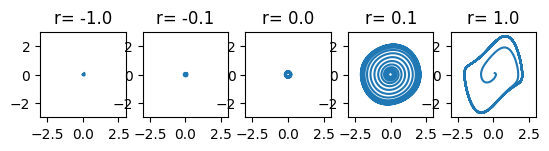

In [2]:
Dt = 0.01

def initialize():
    global x, xresult, y, yresult
    x, y = 0.1, 0.1
    xresult = [x]
    yresult = [y]

def observe():
    global x, xresult, y, yresult
    xresult.append(x)
    yresult.append(y)

def update():
    global x, xresult, y, yresult
    nextx = x + y * Dt
    nexty = y + (-r * (x**2 - 1) * y - x)*Dt
    x, y = nextx, nexty

def plot_phase_space():
    initialize()
    for t in range(10000):
        update()
        observe()
    plot(xresult, yresult)
    axis('image')
    axis([-3, 3, -3, 3])
    title(f'r= {r}')

rs = [-1., -0.1, 0., 0.1, 1.]
for i in range(len(rs)):
    subplot(1, len(rs), i+1)
    r = rs[i]
    plot_phase_space()

show()

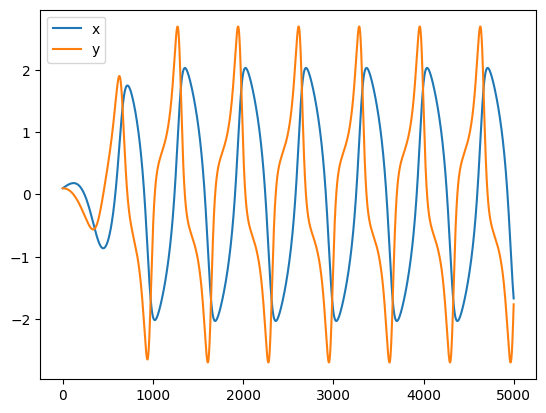

: 

In [ ]:
Dt = 0.01
r = 1

def initialize():
    global x, xresult, y, yresult, t, timestamp
    x, y = 0.1, 0.1
    t = 0
    xresult = [x]
    yresult = [y]
    timestamp = [t]

def observe():
    global x, xresult, y, yresult, t, timestamp
    xresult.append(x)
    yresult.append(y)
    timestamp.append(t)

def update():
    global x, xresult, y, yresult, t, timestamp
    nextx = x + y * Dt
    nexty = y + (-r * (x**2 - 1) * y - x)*Dt
    x, y = nextx, nexty
    t += Dt

initialize()
for t in range(5000):
    update()
    observe()

plot(timestamp, xresult, label= 'x')
plot(timestamp, yresult, label= 'y')
legend()
show()

In [1]:
from pylab import *

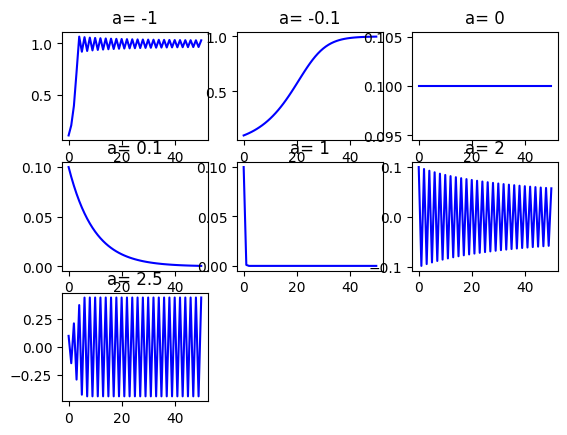

In [7]:
def initialize():
    global x, xresult
    x = 0.1
    xresult = [x]

def observe():
    global x, xresult
    xresult.append(x)

def update():
    global x, xresult
    nextx = (1-a)*x + a*x**3
    x = nextx

def plot_phase_space():
    initialize()
    for t in range(50):
        update()
        observe()
    plot(xresult, 'b-')
    title(f'a= {a}')

a_list = [-1, -0.1, 0, 0.1, 1, 2, 2.5]
for i in range(len(a_list)):
    subplot(3, 3, i+1)
    a = a_list[i]
    plot_phase_space()

show()

In [12]:
from numpy import arange

C:\Users\kekoi\AppData\Local\Temp\ipykernel_21680\1490664232.py:12: RuntimeWarning: overflow encountered in scalar power
  nextx = x + r - x**2


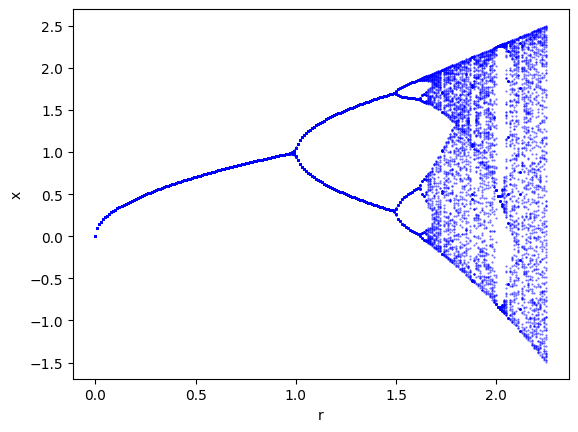

In [22]:
def initialize():
    global x, result
    x = 0.1
    result = []

def observe():
    global x, result
    result.append(x)

def update():
    global x, result
    nextx = x + r - x**2
    x = nextx

def plot_asymptotic_states():
    initialize()
    for t in range(100): # first 100 steps are discarded
        update()
    for t in range(100): # second 100 steps are collected
        update()
        observe()
    plot([r] * 100, result, 'b.', alpha = 0.6, markersize = 1)


for r in arange(0, 3, 0.01):
    plot_asymptotic_states()

xlabel('r')
ylabel('x')
show()